## Review of plotting our data and a regression line

For this example, let's imagine that we have a predictor $x$ and a dependent variable $y$. We construct our data in a way that we know that the "actual" line that we're looking at has an 
- intercept, $\beta_0$ equal to 3 (which we will refer to as $b$ when estimating it)
- $\beta_1$ equal to 50 (which we will refer to as $m$ when estimating it)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(225)

x = np.random.rand(30, 1).reshape(30)
y_randterm = np.random.normal(0,3,30)
y = 3+ 50* x + y_randterm

plt.plot(x, y, '.b')
plt.xlabel("x", fontsize=14)
plt.ylabel("y", fontsize=14);

Let's again come up with some numbers for a slope and a y-intercept.  

>One (not so great) technique to get the slope, is by drawing a line between the first and last points.  And from there, we calculate the value of $b$.  You can use the `build_regression_line` function, defined in our linear_equations library, `linear_equatuions.py`, which quickly does this for us.

In [ ]:
from linear_equations import build_regression_line

Let's pass $x$ and $y$ into our `build_regression_line` function.

In [ ]:
build_regression_line(x,y)

{'slope': 54.550106055369, 'int': 1.3188915249780635}

Turning this into a regression formula, we have the following.

In [ ]:
def regression_formula(x):
    return 1.319 + 54.550*x

Let's plot this regression formula with our data to get a sense of what it looks like.

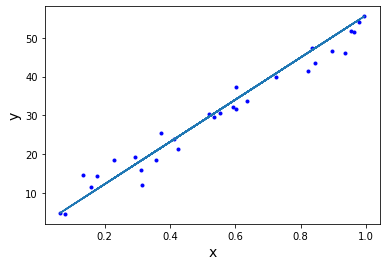

In [ ]:
np.random.seed(225)

x = np.random.rand(30,1).reshape(30)
y_randterm = np.random.normal(0,3,30)
y = 3+ 50* x + y_randterm

plt.plot(x, y, '.b')
plt.plot(x, regression_formula(x), '-')
plt.xlabel("x", fontsize=14)
plt.ylabel("y", fontsize=14);

## Evaluating the regression line

From there, we can calculate the `residual sum of squared errors` and the `root mean squared error`.

In [ ]:
import math

def errors(x_values, y_values, m, b):
    y_line = (b + m*x_values)
    return (y_values - y_line)

def squared_errors(x_values, y_values, m, b):
    return np.round(errors(x_values, y_values, m, b)**2, 2)

def residual_sum_squares(x_values, y_values, m, b):
    return round(sum(squared_errors(x_values, y_values, m, b)), 2)

def root_mean_squared_error(x_values, y_values, m, b):
    return round(math.sqrt(sum(squared_errors(x_values, y_values, m, b)))/len(x_values), 2)

In [ ]:
squared_errors(x, y, 54.550, 1.319 )

array([ 4.44,  0.84, 20.68, 14.68,  2.43, 13.23, 10.31, 10.61,  1.2 ,
        2.04, 38.08,  5.67, 15.21,  0.43,  2.41, 23.48, 37.39,  4.93,
        0.38,  0.7 ,  0.  ,  0.  ,  5.65,  6.94, 40.66,  0.23,  0.89,
        0.  , 11.44,  5.04])

In [ ]:
residual_sum_squares(x, y, 54.550, 1.319) 

279.99

In [ ]:
root_mean_squared_error(x, y, 54.550, 1.319) 

0.56

We can see that the RSS is equal to 279.99 and the RMSE is 0.56 for our regression line! Do you think we can do better?

### Moving towards gradient descent

Now that we have the residual sum of squares function to evaluate the accuracy of our regression line, we can simply try out different regression lines and use the regression line that has the lowest RSS.  The regression line that produces the lowest RSS for a given dataset is called the "best fit" line for that dataset.  

So this will be our technique for finding our "best fit" line:

> * Choose a regression line with a guess of values for $m$ and $b$
> * Calculate the RSS
> * Adjust $m$ and $b$, as these are the only things that can vary in a single-variable regression line.
> * Again calculate the RSS 
> * Repeat this process
> * The regression line (that is, the values of $b$ and $m$) with the smallest RSS is our **best fit line**

We'll eventually tweak and improve upon that process, but for now, it will do.  In fact, we will make things even easier at first by holding $b$ fixed to a constant value while we experiment with different $m$ values.  In later lessons, we will change both variables.

#### Updating the regression line to improve accuracy

Ok, so we have a regression line of $y = mx + b $, and we started with values of $b = 1.319 $ and $m = 54.550 $.  Then seeing how well this regression line matched our dataset, we calculated that $ RSS = 279.99 $.  Our next step is to plug in different values of $m$ and see how RSS changes.  Let's try $m$ = 54 instead of $54.550$.

In [ ]:
residual_sum_squares(x, y, 54, 1.319)

257.35

We can see that the RSS is already lower here! Now let's the RSS for a variety of $m$ values. We'll look at $m$-values between 40 and 59.

In [ ]:
table = np.zeros((20,2))
for idx, val in enumerate(range(40, 60)):
    table[idx,0] = val
    table[idx,1] = residual_sum_squares(x, y, val, 1.319)

In [ ]:
table

array([[  40.  , 2012.31],
       [  41.  , 1738.24],
       [  42.  , 1487.03],
       [  43.  , 1258.71],
       [  44.  , 1053.31],
       [  45.  ,  870.75],
       [  46.  ,  711.05],
       [  47.  ,  574.3 ],
       [  48.  ,  460.37],
       [  49.  ,  369.35],
       [  50.  ,  301.17],
       [  51.  ,  255.89],
       [  52.  ,  233.49],
       [  53.  ,  234.  ],
       [  54.  ,  257.35],
       [  55.  ,  303.64],
       [  56.  ,  372.74],
       [  57.  ,  464.75],
       [  58.  ,  579.66],
       [  59.  ,  717.43]])

Notice what the above table represents.  While keeping our value of $b$ fixed at 1.319, we moved towards a smaller residual sum of squares (RSS) by changing our value of $m$, our slope. 

Setting $m$ to 54 produced a lower error than at 54.550.  We kept moving our $m$ value lower until we set $m$ = 52, at which point our error began to increase.  Therefore, we know that a value of $m$ between 52 and 53 produces the smallest RSS for our data while $b = 1.319$. 

This changing output of RSS based on a changing input of different regression lines is called our **cost function**.  Let's plot this chart to see it better.

We set:

* `m_values` as the input values (x values), and
* `rss_errors` as the output values (y values)

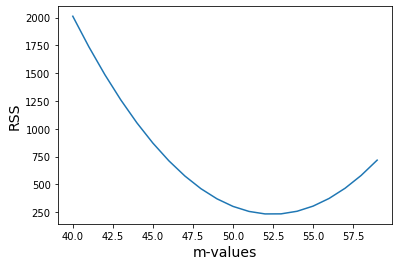

In [ ]:
plt.plot(table[:,0], table[:,1], '-')
plt.xlabel("m-values", fontsize=14)
plt.ylabel("RSS", fontsize=14);

The graph above is called the **cost curve**.  It is a plot of the RSS for different values of $m$.    The curve demonstrates that when $m$ is between 52 and 53, the RSS is lowest.  This technique of optimizing towards a minimum value is called *gradient descent*.  Here, we *descend* along a cost curve.  As we change our variable, we need to stop when the value of our RSS no longer decreases.

Note that we end up with a m-value which is not quite the same as $m$ the value which generated the data. The reason for this is 2-fold:
- We used a value for $b$ which was equal to 1.319, which was quite far from the actual value of 3. Therefore, there is a measurement in error for the slope.
- Secondly, randomness was (intentionally) included in our data, so even with the best algorithm, we would come up with a value *close* to 50, but not exactly 50!

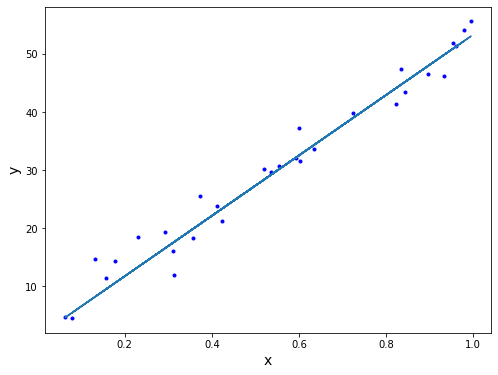

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 

def regression_formula(x):
    return 1.319 + 52*x

np.random.seed(225)

x = np.random.rand(30,1).reshape(30)
y_randterm = np.random.normal(0,3,30)
y = 3+ 50* x + y_randterm

plt.figure(figsize=(8,6))
plt.plot(x, y, '.b')
plt.plot(x, regression_formula(x), '-')
plt.xlabel("x", fontsize=14)
plt.ylabel("y", fontsize=14);

In our cost function below, you can see the sequential values of $m$ and the related RSS values (given a constant value $b$).

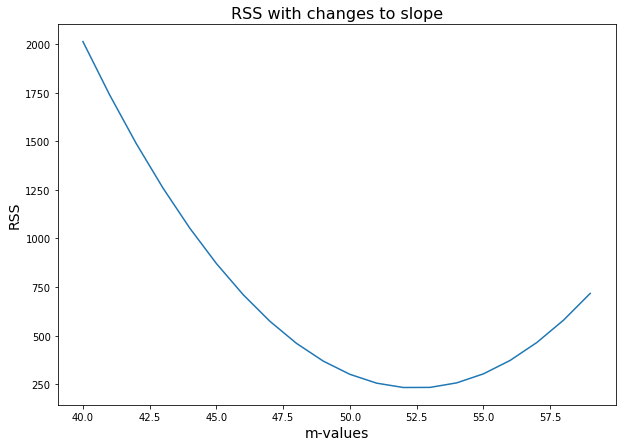

In [ ]:
def errors(x_values, y_values, m, b):
    y_line = (b + m*x_values)
    return (y_values - y_line)

def squared_errors(x_values, y_values, m, b):
    return np.round(errors(x_values, y_values, m, b)**2, 2)

def residual_sum_squares(x_values, y_values, m, b):
    return round(sum(squared_errors(x_values, y_values, m, b)), 2)


table = np.zeros((20,2))
for idx, val in enumerate(range(40, 60)):
    table[idx,0] = val
    table[idx,1] = residual_sum_squares(x, y, val, 1.319)
    
plt.figure(figsize=(10,7))
plt.plot(table[:,0], table[:,1], '-')
plt.xlabel("m-values", fontsize=14)
plt.ylabel("RSS", fontsize=14)
plt.title("RSS with changes to slope", fontsize=16);

> The bottom of the blue curve displays the $m$ value that produces the lowest RSS.

### Things are not so simple

At this point, our problem of finding the minimum RSS may seem simple.  For example, why not simply try **all** of the different values for the slope, and find the value where RSS is the lowest? 

So far, we have held one variable, the y-intercept, constant in order to experiment with the other. We need an approach that will continue to work as we change both of the variables in our regression line.  Altering the second variable makes things far more complicated.  Here is a quick look at our cost curve if we can change both our slope value $m$ *and* the y-intercept $b$:

<img src="./assets/gradient_descent_basics/new_gradientdescent.png" width="600">

As we can see, exploring both variables (the slope and the y-intercept) requires plotting the second variable along the horizontal axis and turning our graph into a three-dimensional representation.  And in the future, we'll be able to change more than just that.  

Furthermore, because we need to explore multiple variables in our regression lines, we are forced to rule out some approaches that are more computationally expensive, or simply not possible.

* We **cannot** simply use the derivative (more on that later) to find the minimum.  Using that approach will be impossible in many scenarios as our regression lines become more complicated.
* We **cannot** alter all of the variables of our regression line across all points and calculate the result.  It will take too much time, as we have more variables to alter. 

However, we are on the right track by altering our regression line and calculating the resulting RSS values.

Remember in the last lesson, we evaluated our regression line by changing our slope by 1 to determine whether it produced a higher or lower RSS.  

| m       | residual sum of squared           | 
| ------------- |:-------------:| 
|  44  | 1053.31|
|  45  |  870.75|
| 46  |  711.05|
|  47  |  574.3 |
|48  |  460.37|
|49  |  369.35|
|  50  | 301.17|
|  51  |  255.89|
|  52  |  233.49|
|  53  |  234  |
|  54  | 257.35|
| 55  | 303.64|
|  56  |  372.74|

Rather than arbitrarily changing our variables, as we have done by decrementing the slope value $m$ by 1 in the example above, we need to move carefully down the cost curve to be certain that our changes are reducing the RSS.

### Our approach

We don't want to adjust the slope value $m$ or another variable and hope that the RSS decreased.  Doing so is like trying to fly a plane just by sitting down and pressing buttons.  

We want an approach that lets us be certain that we're moving in the right direction with every change.  Also, we want to know how much of a **change** to make to minimize RSS.

> Let's call each of these changes a **step**, and the size of the change our **step size**. 

Our new task is to find step sizes that bring us to the best RSS quickly without overshooting the mark.

![](./assets/gradient_descent_basics/aden-and-cree.jpg)

### The slope of the cost curve tells us our step size

Believe it or not, we can determine the proper step size just by looking at the slope of our cost function.

Imagine yourself standing on our cost curve like a skateboarder at the top of a halfpipe.  Even with your eyes closed, you could tell simply *by the way you tilted* whether to move forward or backward to approach the bottom of the cost curve.  

<img src="./assets/gradient_descent_basics/snowboard.png" width="600">

* If the slope tilts downwards, then we should walk forward to approach the minimum.  
* And if the slope tilts upwards, then we should point walk backwards to approach the minimum.  
* The steeper the tilt, the further away we are from our cost curve's minimum, so we should take a larger step.  

So by looking to the tilt of a cost curve at a given point, we can discover the direction of our next step and how large a step to take.  The beauty of this is that as our regression lines become more complicated, we need not plot all of the values of our regression line.  We can see the next variation of the regression line to study simply by looking at the slope of the cost curve.

To demonstrate this, let's look at our cost function. By adding the slopes at some of the points on the curve, we can get a sense of the direction and magnitude of change required to alter our linear regression slope $m$ in the next iteration.

In [ ]:
table_sm = np.zeros((401,2))
for idx, val in enumerate(np.linspace(40, 60, 401)):
    table_sm[idx,0] = val
    table_sm[idx,1] = residual_sum_squares(x, y, val, 1.319)

In [ ]:
def tan_line(start, stop, delta_a):
    x_dev = np.linspace(start, stop, 100)
    a = (start+stop)/2 
    f_a= table_sm[(table_sm[:,0]==a),1]
    rounded_a_delta_a = round(a+delta_a,2)
    f_a_delta= table_sm[(table_sm[:,0]== (rounded_a_delta_a)),1]
    fprime = (f_a_delta-f_a)/delta_a 
    tan = f_a+fprime*(x_dev-a)
    return fprime, x_dev, tan

In [ ]:
fprime_1, x_dev_1, y_dev_1 = tan_line(41, 43.5, 0.05)
fprime_2, x_dev_2,  y_dev_2 = tan_line(45, 48, 0.05)
fprime_3, x_dev_3,  y_dev_3 = tan_line(49, 52, 0.05)

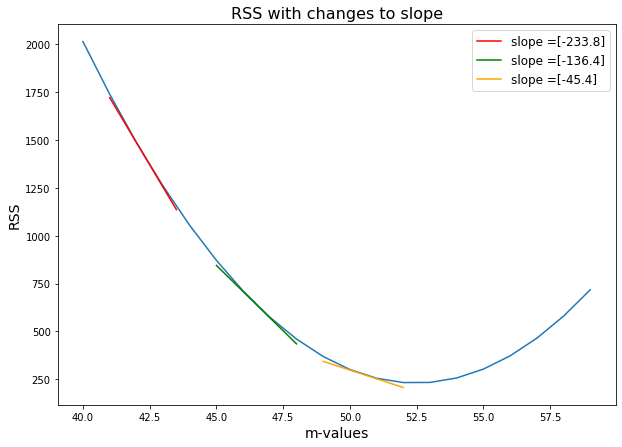

In [ ]:
plt.figure(figsize=(10,7))
plt.plot(table[:,0], table[:,1], '-')
plt.plot(x_dev_1, y_dev_1, color = "red",  label = "slope =" + str(fprime_1))
plt.plot(x_dev_2, y_dev_2, color = "green",  label = "slope =" + str(fprime_2))
plt.plot(x_dev_3, y_dev_3, color = "orange", label = "slope =" + str(fprime_3))

plt.xlabel("m-values", fontsize=14)
plt.ylabel("RSS", fontsize=14)
plt.legend(loc='upper right', fontsize='large')

plt.title("RSS with changes to slope", fontsize=16);

### Stepping according to the slope

When you look at the above plot in detail you can see that we added numbers to our slope.  The slope of the curve at any given point is equal to the slope of the tangent line at that point.  By tangent line, we mean the line that just barely touches the curve at that point.  In the above graph, the red, green and orange lines are tangent to our cost curve at the points where $m$ equals 42.25, 46.5, and 50.5, respectively.  The slopes of our tangent lines, and therefore the slopes of the cost curves at those points, are labeled above.  

Let's see how this works.

We use the following procedure to find the ideal $m$: 
1.  Randomly choose a value of $m$, and 
2.  Update $m$ with the formula $ m = (-.02) * slope_{m = i} + m_i$.

The formula above tells us which $m$ value to look at next. We start by choosing a random $m$ value that we can plug into our formula. We take the slope of the curve at that $m$ value and multiply it by $-.02$ then add it to our original $m$ value to produce our next $m$ value.

As we can surmise, the larger the slope, the larger the resulting step to the next $m$ value.

Here's an example.  We randomly choose a $m$ value of 42.  Then:

* $m_{t=0} = 42 $
* $m_{t=1} = (-.02) * -239  + 42 = 4.78 + 42 = 46.78 $
* $m_{t=2} = (-.02) * -129.4 + 46.8 = 2.588 + 46.8 = 49.388 $

* $m_{t=3} = (-.02) * -60.4 + 49.4 = 1.208 + 49.4 = 50.61  $

> Notice that we don't update our values of $m$ by just adding or subtracting the slope at that point.  The reason we multiply the slope by a fraction like .02 is so that we avoid the risk of overshooting the minimum.  This fraction is called the **learning rate**.  Here, the fraction is negative because we always want to move in the opposite direction of the slope. When the slope of the cost curve points downwards, we want to move to a higher $m$ slope for our linear regression problem. Conversely, when we are on the right side of the curve and the slope is rising, we want to move backwards to a lower y-intercept.

This technique is pretty magical.  By looking at the tangent line at each point, we no longer are  changing our $m$ value and just hoping that it has the correct impact on our RSS.  This is because, for one, the slope of the tangent line points us in the right direction.  And as you can see above, our technique properly adjusts the amount to change the $m$ value without even knowing the ideal $m$ value.  When our $m$ was far away from the ideal $m$ value, our formula increased $m$ by almost 5. By the third step, we were updating our $m$ value by only 1.2 because we were closer to the ideal slope for minimizing the RSS.

## Setting up our initial regression line

Once again, we'll take a look at revenues our data example, which looks like this:

In [ ]:
import numpy as np
np.set_printoptions(formatter={'float_kind':'{:f}'.format})
import matplotlib.pyplot as plt
np.random.seed(225)

x = np.random.rand(30, 1).reshape(30)
y_randterm = np.random.normal(0,3,30)
y = 3+ 50* x + y_randterm

plt.plot(x, y, '.b')
plt.xlabel("x", fontsize=14)
plt.ylabel("y", fontsize=14);

We can start with some values for an initial not-so-accurate regression line, $y = 43x + 12$.

In [ ]:
def regression_formula(x):
    return 12 + 43*x

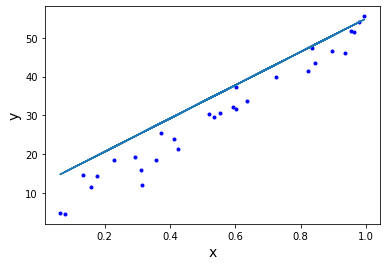

In [ ]:
np.random.seed(225)

x = np.random.rand(30,1).reshape(30)
y_randterm = np.random.normal(0,3,30)
y = 3+ 50* x + y_randterm

plt.plot(x, y, '.b')
plt.plot(x, regression_formula(x), '-')
plt.xlabel("x", fontsize=14)
plt.ylabel("y", fontsize=14);

In [ ]:
def errors(x_values, y_values, m, b):
    y_line = (b + m*x_values)
    return (y_values - y_line)

def squared_errors(x_values, y_values, m, b):
    return errors(x_values, y_values, m, b)**2

def residual_sum_squares(x_values, y_values, m, b):
    return sum(squared_errors(x_values, y_values, m, b))

Now using the `residual_sum_squares`, function, we calculate the RSS to measure the accuracy of the regression line to our data.  Let's take another look at that function:

In [ ]:
residual_sum_squares(x, y , 43, 12) 

1117.8454014417434

### Building a cost curve

Now let's use the `residual_sum_squares` function to build a cost curve.  Keeping the $m$ value fixed at $43$, write a function called `rss_values`.  
* `rss_values` passes our dataset with the `x_values` and `y_values` arguments.  
* It also takes a list of values of $b$, and an initial $m$ value as arguments.  
* It outputs a numpy array with a first column of `b_values` and `rss_values`, with each key pointing to a list of the corresponding values.

In [ ]:
def rss_values(x_values, y_values, m, b_values):
    b_min = min(b_values)
    b_max = max(b_values)
    table = np.zeros((((b_max-b_min)*2)+1,2))
    for idx, val in enumerate(np.linspace(b_min, b_max, ((b_max-b_min)*2)+1)):
        table[idx,0] = val
        table[idx,1] = residual_sum_squares(x_values, y_values, 43, val)
    return table

Now loop over a list with $b$ values between 0 and 14 with steps of 0.5. Store it in bval_RSS. Print out the resulting table.

In [ ]:
import sys
b_val = list(range(0, 15, 1))
bval_RSS = rss_values(x,y,43,b_val)
np.savetxt(sys.stdout, bval_RSS, '%16.2f')  #this line is to round your result, which will make things look nicer.

            0.00          1750.97
            0.50          1552.09
            1.00          1368.21
            1.50          1199.33
            2.00          1045.45
            2.50           906.57
            3.00           782.69
            3.50           673.81
            4.00           579.93
            4.50           501.05
            5.00           437.17
            5.50           388.29
            6.00           354.41
            6.50           335.53
            7.00           331.65
            7.50           342.77
            8.00           368.89
            8.50           410.01
            9.00           466.13
            9.50           537.25
           10.00           623.37
           10.50           724.49
           11.00           840.61
           11.50           971.73
           12.00          1117.85
           12.50          1278.97
           13.00          1455.08
           13.50          1646.20
           14.00          1852.32


Plotly provides for us a table chart, and we can pass the values generated from our `rss_values` function to create a table.

And let's plot this out using a a line chart.

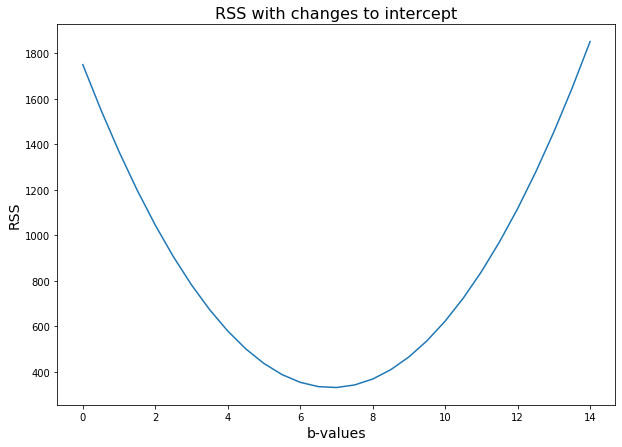

In [ ]:
plt.figure(figsize=(10,7))
plt.plot(bval_RSS[:,0], bval_RSS[:,1], '-')
plt.xlabel("b-values", fontsize=14)
plt.ylabel("RSS", fontsize=14)
plt.title("RSS with changes to intercept", fontsize=16);

## Looking at the slope of our cost curve

In this section, we'll work up to building a gradient descent function that automatically changes our step size.  To get you started, we'll provide a function called `slope_at` that calculates the slope of the cost curve at a given point on the cost curve. Use the `slope_at` function for b-values 3 and 6.

In [ ]:
def slope_at(x_values, y_values, m, b):
    delta = .001
    base_rss = residual_sum_squares(x_values, y_values, m, b)
    delta_rss = residual_sum_squares(x_values, y_values, m, b + delta)
    numerator = delta_rss - base_rss
    slope = numerator/delta
    return {'b': b, 'slope': slope}

In [ ]:
# Use slope_at
slope_at(x, y, 43, 3)
#{'b': 3, 'slope': -232.73066022784406}

{'b': 3, 'slope': -232.73066022784406}

In [ ]:
# Use slope_at
slope_at(x, y, 43, 6)
{'b': 6, 'slope': -52.73066022772355}

{'b': 6, 'slope': -52.73066022772355}

So the `slope_at` function takes in our dataset, and returns the slope of the cost curve at that point.  So the numbers -232.73 and -52.73 reflect the slopes at the cost curve when b is 3 and 6 respectively.

In [ ]:
slope_3= slope_at(x, y, 43, 3)['slope']
slope_6 = slope_at(x, y, 43, 6)['slope']

x_3 = np.linspace(3-1, 3+1, 100)
x_6 = np.linspace(6-1, 6+1, 100)

rss_3 = residual_sum_squares(x, y, 43, 3)
rss_6 = residual_sum_squares(x, y, 43, 6)

tan_3 = rss_3+slope_3*(x_3-3)
tan_6 = rss_6+slope_6*(x_6-6)

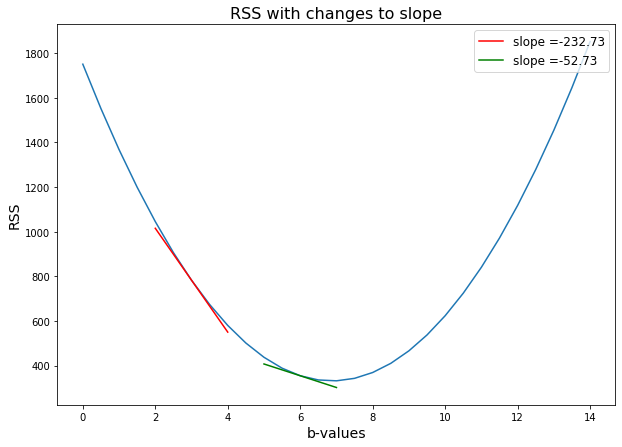

In [ ]:
plt.figure(figsize=(10,7))
plt.plot(bval_RSS[:,0], bval_RSS[:,1], '-')
plt.plot(x_3, tan_3, color = "red",  label = "slope =" + str(round(slope_3,2)))
plt.plot(x_6, tan_6, color = "green",  label = "slope =" + str(round(slope_6,2)))

plt.xlabel("b-values", fontsize=14)
plt.ylabel("RSS", fontsize=14)
plt.legend(loc='upper right', fontsize='large')

plt.title("RSS with changes to slope", fontsize=16);

As you can see, it seems pretty accurate.  When the curve is steeper and downwards at $b = 3$, the slope is around -232.73.  And at $b = 6$ with our cost curve becoming flatter, our slope is around -52.73. 

## Moving towards gradient descent

Now that we are familiar with our `slope_at` function and how it calculates the slope of our cost curve at a given point, we can begin to use that function with our gradient descent procedure.

Remember that gradient descent works by starting at a regression line with values m, and b, which corresponds to a point on our cost curve.  Then we alter our m or b value (here, the b value) by looking to the slope of the cost curve at that point.  Then we look to the slope of the cost curve at the new b value to indicate the size and direction of the next step.

So now let's write a function called `updated_b`.  The function will tell us the step size and direction to move along our cost curve.  The `updated_b` function takes as arguments an initial value of $b$, a learning rate, and the `slope` of the cost curve at that value of $m$.  Its return value is the next value of `b` that it calculates.

In [ ]:
def updated_b(b, learning_rate, cost_curve_slope):
    change_to_b = -1 * learning_rate * cost_curve_slope
    return change_to_b + b

This is what our function returns.

In [ ]:
current_slope = slope_at(x, y, 43, 3)['slope']
updated_b(3, .01, current_slope)
# 5.327

5.3273066022784406

In [ ]:
current_slope = slope_at(x, y, 43, 5.327)['slope']
updated_b(5.327, .01, current_slope)
# 6.258

6.2581066022854674

In [ ]:
current_slope = slope_at(x, y, 43, 6.258)['slope']
updated_b(6.258, .01, current_slope)
# 6.6305

6.630506602279827

In [ ]:
current_slope = slope_at(x, y, 43, 6.631)['slope']
updated_b(6.631, .01, current_slope)
# 6.780

6.779706602280413

Take a careful look at how we use the `updated_b` function.  By using our updated value of $b$ we are quickly converging towards an optimal value of $b$.   

Now let's write another function called `gradient_descent`.  The inputs of the function are `x_values`, `y_values`, `steps`, the `m` we are holding constant, the `learning_rate`, and the `current_b` that we are looking at.  The `steps` arguments represent the number of steps the function will take before the function stops.  We can get a sense of the return value in the cell below.  It is a list of dictionaries, with each dictionary having a key of the current `b` value, the `slope` of the cost curve at that `b` value, and the `rss` at that `b` value.

In [ ]:
def gradient_descent(x_values, y_values, steps, current_b, learning_rate, m):
    cost_curve = []
    for i in range(steps):
        current_cost_slope = slope_at(x_values, y_values, m, current_b)['slope']
        current_rss = residual_sum_squares(x_values, y_values, m, current_b)
        cost_curve.append({'b': current_b, 'rss': round(current_rss,2), 'slope': round(current_cost_slope,2)})
        current_b = updated_b(current_b, learning_rate, current_cost_slope)
    return cost_curve

In [ ]:
descent_steps = gradient_descent(x, y, 15, 0, learning_rate = .005, m = 43)
descent_steps

#[{'b': 0, 'rss': 1750.97, 'slope': -412.73},
# {'b': 2.063653301142949, 'rss': 1026.94, 'slope': -288.91},
# {'b': 3.5082106119386935, 'rss': 672.15, 'slope': -202.24},
# {'b': 4.519400729495828, 'rss': 498.29, 'slope': -141.57},
# {'b': 5.2272338117862205, 'rss': 413.1, 'slope': -99.1},
# {'b': 5.72271696938941, 'rss': 371.35, 'slope': -69.37},
# {'b': 6.06955517971187, 'rss': 350.88, 'slope': -48.56},
# {'b': 6.312341926937677, 'rss': 340.86, 'slope': -33.99},
# {'b': 6.482292649996282, 'rss': 335.94, 'slope': -23.79},
# {'b': 6.601258156136964, 'rss': 333.53, 'slope': -16.66},
# {'b': 6.684534010435641, 'rss': 332.35, 'slope': -11.66},
# {'b': 6.742827108444089, 'rss': 331.77, 'slope': -8.16},
# {'b': 6.7836322770506285, 'rss': 331.49, 'slope': -5.71},
# {'b': 6.812195895074922, 'rss': 331.35, 'slope': -4.0},
# {'b': 6.832190427692808, 'rss': 331.28, 'slope': -2.8}]

[{'b': 0, 'rss': 1750.97, 'slope': -412.73},
 {'b': 2.063653301142949, 'rss': 1026.94, 'slope': -288.91},
 {'b': 3.5082106119386935, 'rss': 672.15, 'slope': -202.24},
 {'b': 4.519400729495828, 'rss': 498.29, 'slope': -141.57},
 {'b': 5.2272338117862205, 'rss': 413.1, 'slope': -99.1},
 {'b': 5.72271696938941, 'rss': 371.35, 'slope': -69.37},
 {'b': 6.06955517971187, 'rss': 350.88, 'slope': -48.56},
 {'b': 6.312341926937677, 'rss': 340.86, 'slope': -33.99},
 {'b': 6.482292649996282, 'rss': 335.94, 'slope': -23.79},
 {'b': 6.601258156136964, 'rss': 333.53, 'slope': -16.66},
 {'b': 6.684534010435641, 'rss': 332.35, 'slope': -11.66},
 {'b': 6.742827108444089, 'rss': 331.77, 'slope': -8.16},
 {'b': 6.7836322770506285, 'rss': 331.49, 'slope': -5.71},
 {'b': 6.812195895074922, 'rss': 331.35, 'slope': -4.0},
 {'b': 6.832190427692808, 'rss': 331.28, 'slope': -2.8}]

Looking at our b-values, you get a pretty good idea of how our gradient descent function works.  It starts far away with $b = 0$, and the step size is relatively large, as is the slope of the cost curve.  As the $b$ value updates such that it approaches a minimum of the RSS, the slope of the cost curve and the size of each step both decrease.     

Remember that each of these steps indicates a change in our regression line's slope value towards a "fit" that more accurately matches our dataset.  Let's plot the final regression line as found before, with $m=43$ and $b=6.83$

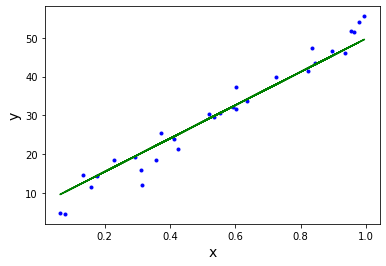

In [ ]:
np.random.seed(225)
x = np.random.rand(30,1).reshape(30)
y_randterm = np.random.normal(0,3,30)
y = 3+ 50 * x + y_randterm

plt.plot(x, y, '.b')
plt.plot(x, (43*x + 6.83), '-', color="green")
plt.xlabel("x", fontsize=14)
plt.ylabel("y", fontsize=14);